 # Image Captioning con TensorFlow y Flickr8k



 ## Sistema de descripción automática de imágenes



 **Arquitectura**: Encoder-Decoder con VGG16 + LSTM con atención

 ## 1. Configuración inicial

In [2]:
# Verificar e instalar dependencias
#try:
    #import tensorflow as tf
    #print(f"TensorFlow {tf.__version__} ya está instalado")
#except ImportError:
    #pip install tensorflow numpy matplotlib pillow nltk tqdm pycocotools
    #import tensorflow as tf


In [1]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to C:\Users\Gerard/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Gerard/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

 ## 2. Imports y configuración

In [2]:
# Importar librerías
import os
import numpy as np
from pathlib import Path
from PIL import Image
import tensorflow as tf
import string
import datetime
import re
from collections import Counter
import ssl
import nltk  # Importamos nltk al inicio para evitar problemas de scope

# Configuración SSL para NLTK
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

# Descargar recursos NLTK (versión mejorada)
def setup_nltk():
    required_resources = {
        'punkt': ['tokenizers/punkt'],
        'wordnet': ['corpora/wordnet'],
        'averaged_perceptron_tagger': ['taggers/averaged_perceptron_tagger'],
        'stopwords': ['corpora/stopwords']
    }
    
    print("Configurando recursos NLTK...")
    
    # Verificar si los datos están en la ubicación correcta
    nltk_data_path = os.path.join(os.path.expanduser("~"), "nltk_data")
    if not os.path.exists(nltk_data_path):
        os.makedirs(nltk_data_path)
    for resource, subpaths in required_resources.items():
        try:
            # Verificar si ya está descargado
            all_downloaded = True
            for subpath in subpaths:
                try:
                    nltk.data.find(subpath)
                except LookupError:
                    all_downloaded = False
                    break
            
            if not all_downloaded:
                print(f"Descargando recurso: {resource}...")
                nltk.download(resource, quiet=False)
                print(f"Recurso {resource} instalado correctamente")
            else:
                print(f"Recurso {resource} ya está instalado")
                
        except Exception as e:
            print(f"\n⚠️ Error al configurar {resource}: {str(e)}")
            print("Puedes intentar descargarlo manualmente con:")
            print(f"import nltk; nltk.download('{resource}')\n")

# Ejecutar la configuración
setup_nltk()

# Resto de tus imports de TensorFlow/Keras
from tensorflow.keras.layers import (Input, Dense, Embedding, LSTM, Concatenate,  Dropout, BatchNormalization, Layer, GlobalAveragePooling2D)
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, TensorBoard)

from nltk.tokenize import word_tokenize
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

from tqdm import tqdm
from IPython.display import display, Markdown

# Configurar paths
class Config:
    def __init__(self):
        # Ruta específica para tu sistema
        self.BASE_DIR = Path(r"C:\Users\Gerard\Desktop\VISUAL_STUDIO\Descrpicion_Automatica_Imagenes\Flickr8k")
        self.IMAGE_DIR = self.BASE_DIR / "Flicker8k_Dataset"
        self.TRAIN_FILE = self.BASE_DIR / "Flickr_8k.trainImages.txt"
        self.TEST_FILE = self.BASE_DIR / "Flickr_8k.testImages.txt"
        self.DESCRIPTIONS_FILE = self.BASE_DIR / "Flickr8k.token.txt"
        
        # Verificar existencia de directorios y archivos
        self._verify_paths()

    def _verify_paths(self):
        """Verifica que los paths existan"""
        required_paths = {
            "Directorio base": self.BASE_DIR,
            "Directorio de imágenes": self.IMAGE_DIR,
            "Archivo de entrenamiento": self.TRAIN_FILE,
            "Archivo de prueba": self.TEST_FILE,
            "Archivo de descripciones": self.DESCRIPTIONS_FILE
        }
        
        missing = False
        for name, path in required_paths.items():
            if not path.exists():
                print(f"❌ {name} no encontrado en: {path}")
                missing = True
            else:
                print(f"✅ {name} encontrado")
        
        if missing:
            raise FileNotFoundError("Faltan archivos/directorios requeridos. Verifica las rutas.")

config = Config()

Configurando recursos NLTK...
Recurso punkt ya está instalado
Descargando recurso: wordnet...
Recurso wordnet instalado correctamente
Recurso averaged_perceptron_tagger ya está instalado
Recurso stopwords ya está instalado
✅ Directorio base encontrado
✅ Directorio de imágenes encontrado
✅ Archivo de entrenamiento encontrado
✅ Archivo de prueba encontrado
✅ Archivo de descripciones encontrado


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Gerard/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


 ## 3. Carga y preparación de datos

In [3]:
def load_image_ids(file_path):
    """Carga IDs de imágenes desde archivo"""
    if not file_path.exists():
        raise FileNotFoundError(f"Archivo no encontrado: {file_path}")
    
    with open(file_path, 'r', encoding='utf-8') as f:
        return [line.strip().split('.')[0] for line in f if line.strip()]

def load_descriptions(file_path):
    """Carga y normaliza descripciones"""
    descriptions = {}
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line or '\t' not in line:
                continue
                
            img_id, desc = line.split('\t')
            img_id = img_id.split('.')[0]
            desc = desc.lower().translate(str.maketrans('', '', string.punctuation))
            
            descriptions.setdefault(img_id, []).append(desc)
    
    return descriptions

# Cargar datos
train_ids = load_image_ids(config.TRAIN_FILE)
test_ids = load_image_ids(config.TEST_FILE)
all_descriptions = load_descriptions(config.DESCRIPTIONS_FILE)

# Filtrar descripciones
train_descriptions = {k: all_descriptions[k] for k in train_ids if k in all_descriptions}
test_descriptions = {k: all_descriptions[k] for k in test_ids if k in all_descriptions}

print(f"✔ Imágenes de entrenamiento: {len(train_ids)}")
print(f"✔ Imágenes de prueba: {len(test_ids)}")
print(f"✔ Descripciones de entrenamiento: {len(train_descriptions)}")
print(f"✔ Descripciones de prueba: {len(test_descriptions)}")


✔ Imágenes de entrenamiento: 6000
✔ Imágenes de prueba: 1000
✔ Descripciones de entrenamiento: 6000
✔ Descripciones de prueba: 1000


 ## 4. Construcción del vocabulario

In [5]:
def build_vocabulary(descriptions, min_count=5):  # Cambiado de 3 a 5 para reducir vocabulario ruidoso
    """Construye vocabulario con filtrado mejorado"""
    word_counts = Counter()
    
    for desc_list in tqdm(descriptions.values(), desc="Procesando descripciones"):
        for desc in desc_list:
            # Mejor filtrado de tokens
            tokens = word_tokenize(desc.lower())
            tokens = [t for t in tokens if t.isalpha() and len(t) > 1]  # Excluir palabras de 1 letra
            word_counts.update(tokens)
    
    # Vocabulario más robusto
    vocab = ['<start>', '<end>', '<pad>', '<unk>'] + \
            [word for word, count in word_counts.items() if count >= min_count]
    
    print(f"\nVocabulario creado: {len(vocab)} palabras")
    print("20 palabras más frecuentes:", word_counts.most_common(20))
    
    return vocab, {word: idx for idx, word in enumerate(vocab)}, \
        {idx: word for idx, word in enumerate(vocab)}

vocabulary, word_to_idx, idx_to_word = build_vocabulary(train_descriptions, min_count=3)
vocab_size = len(vocabulary)


Procesando descripciones: 100%|██████████| 6000/6000 [00:01<00:00, 3978.20it/s]


Vocabulario creado: 3473 palabras
20 palabras más frecuentes: [('in', 14085), ('the', 13509), ('on', 8006), ('is', 6907), ('and', 6672), ('dog', 6159), ('with', 5763), ('man', 5374), ('of', 4967), ('two', 4246), ('white', 2921), ('black', 2854), ('boy', 2634), ('are', 2619), ('woman', 2543), ('girl', 2414), ('to', 2303), ('wearing', 2271), ('at', 2101), ('people', 2093)]


 ## 5. Preprocesamiento de descripciones

In [5]:
def preprocess_descriptions(descriptions, word_to_idx):
    """Convierte texto a secuencias de índices"""
    processed = {}
    max_length = 0
    
    for img_id, desc_list in tqdm(descriptions.items(), desc="Preprocesando"):
        processed[img_id] = []
        for desc in desc_list:
            words = word_tokenize(desc.lower())
            seq = [word_to_idx.get(word, word_to_idx['<unk>']) for word in words 
                if word in word_to_idx or word.isalpha()]
            if len(seq) > max_length:
                max_length = len(seq)
            processed[img_id].append(seq)
    
    return processed, max_length

train_descriptions_processed, max_seq_length = preprocess_descriptions(train_descriptions, word_to_idx)
test_descriptions_processed, _ = preprocess_descriptions(test_descriptions, word_to_idx)

print(f"\nLongitud máxima de secuencia: {max_seq_length}")


Preprocesando: 100%|██████████| 1000/1000 [00:00<00:00, 1547.45it/s]


Longitud máxima de secuencia: 35


 ## 6. Modelo Encoder-Decoder con Atención

In [34]:
class BahdanauAttention(Layer):
    def __init__(self, units, **kwargs):
        super(BahdanauAttention, self).__init__(**kwargs)
        self.W1 = Dense(units, kernel_regularizer=l2(0.01))
        self.W2 = Dense(units, kernel_regularizer=l2(0.01))
        self.V = Dense(1, kernel_regularizer=l2(0.01))
        self.units = units

    def call(self, features, hidden):
        hidden_with_time_axis = tf.expand_dims(hidden, 1)
        score = self.V(tf.nn.tanh(
            self.W1(features) + self.W2(hidden_with_time_axis)))
        attention_weights = tf.nn.softmax(score, axis=1)
        context_vector = attention_weights * features
        context_vector = tf.reduce_sum(context_vector, axis=1)
        return context_vector, attention_weights

def create_decoder(vocab_size, max_length, embedding_dim=300, lstm_units=512):
    """Decoder mejorado con regularización"""
    # Inputs
    image_input = Input(shape=(512,), name='image_features')
    caption_input = Input(shape=(max_length,), name='caption_input')
    
    # Capa de imagen
    img_features = Dense(embedding_dim, activation='relu', 
                        kernel_regularizer=l2(0.01))(image_input)
    img_features = BatchNormalization()(img_features)
    img_features = Dropout(0.4)(img_features)
    
    # Embedding de texto
    text_embed = Embedding(
        vocab_size, 
        embedding_dim, 
        mask_zero=True,
        embeddings_initializer='glorot_uniform'
    )(caption_input)
    text_embed = Dropout(0.5)(text_embed)
    
    # LSTM
    lstm = LSTM(
        lstm_units,
        return_sequences=True,
        return_state=True,
        recurrent_dropout=0.3,
        kernel_regularizer=l2(0.01),
        recurrent_regularizer=l2(0.01)
    )
    lstm_output, state_h, state_c = lstm(text_embed)
    
    # Atención
    attention = BahdanauAttention(lstm_units)
    context_vector, _ = attention(lstm_output, img_features)
    
    # Decodificación
    combined = Concatenate()([context_vector, img_features])
    decoder_output = Dense(lstm_units, activation='relu',
                        kernel_regularizer=l2(0.01))(combined)
    decoder_output = Dropout(0.4)(decoder_output)
    decoder_output = BatchNormalization()(decoder_output)
    output = Dense(vocab_size, activation='softmax')(decoder_output)
    
    # Modelo
    decoder = Model(inputs=[image_input, caption_input], outputs=output)
    
    # Compilación CORREGIDA (optimizador mejorado)
    optimizer = Adam(
        learning_rate=0.00005,  # 5e-5
        clipnorm=1.0,           # Usamos solo clipnorm (no clipvalue)
        beta_1=0.9,
        beta_2=0.999,
        epsilon=1e-07
    )
    
    decoder.compile(
        optimizer=optimizer, 
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return decoder

def create_encoder():
    """Crea el encoder VGG16"""
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False  # Congelar capas
    
    # Capa de salida
    flatten = GlobalAveragePooling2D()(base_model.output)
    encoder = Model(inputs=base_model.input, outputs=flatten)
    
    return encoder

encoder = create_encoder()
decoder = create_decoder(vocab_size, max_seq_length)

# Resumen
decoder.summary()

C:\Users\Gerard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\layer.py:932: UserWarning: Layer 'bahdanau_attention_7' (of type BahdanauAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ caption_input       │ (None, 35)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_features      │ (None, 512)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_7         │ (None, 35, 300)   │  1,041,900 │ caption_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_42 (Dense)    │ (None, 300)       │    153,900 │ image_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_22          │ (None, 35, 300)   │          0 │ embedding_7[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_7         │ (None, 35)        │          0 │ caption_input[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300)       │      1,200 │ dense_42[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_7 (LSTM)       │ [(None, 35, 512), │  1,665,024 │ dropout_22[0][0], │
│                     │ (None, 512),      │            │ not_equal_7[0][0] │
│                     │ (None, 512)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_21          │ (None, 300)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bahdanau_attention… │ [(None, 512),     │    417,281 │ lstm_7[0][0],     │
│ (BahdanauAttention) │ (None, 35, 1)]    │            │ dropout_21[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 812)       │          0 │ bahdanau_attenti… │
│ (Concatenate)       │                   │            │ dropout_21[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_46 (Dense)    │ (None, 512)       │    416,256 │ concatenate_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_23          │ (None, 512)       │          0 │ dense_46[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dropout_23[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_47 (Dense)    │ (None, 3473)      │  1,781,649 │ batch_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,479,258 (20.90 MB)

 Trainable params: 5,477,634 (20.90 MB)

 Non-trainable params: 1,624 (6.34 KB)

 ## 7. Extracción de características

In [10]:
def preprocess_image(image_path):
    """Preprocesa imagen para VGG16"""
    img = Image.open(image_path).convert('RGB')
    img = img.resize((224, 224))
    img_array = np.array(img) / 255.0
    return preprocess_input(img_array)

def extract_features(image_ids, image_dir):
    """Extrae características usando el encoder"""
    features = {}
    for img_id in tqdm(image_ids, desc="Extrayendo características"):
        img_path = image_dir / f"{img_id}.jpg"
        img_array = np.expand_dims(preprocess_image(img_path), axis=0)
        features[img_id] = encoder.predict(img_array, verbose=0)[0]
    return features

# Extraer características (esto puede tardar)
train_features = extract_features(train_ids, config.IMAGE_DIR)
test_features = extract_features(test_ids, config.IMAGE_DIR)


Extrayendo características: 100%|██████████| 1000/1000 [04:28<00:00,  3.72it/s]


In [35]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Configurar aumento de datos
train_datagen = ImageDataGenerator(
    rotation_range=25,  # Aumentado
    width_shift_range=0.15,
    height_shift_range=0.15,
    brightness_range=[0.8, 1.2],  # Nuevo
    zoom_range=0.2,
    fill_mode='constant',  # Rellenar con negro
    cval=0.0
)

def augmented_extract_features(image_ids, image_dir):
    """Extrae características con aumento de datos"""
    features = {}
    for img_id in tqdm(image_ids, desc="Extrayendo características (con aumento)"):
        img_path = image_dir / f"{img_id}.jpg"
        img = Image.open(img_path).convert('RGB')
        img = img.resize((224, 224))
        
        # Extraer características de la imagen original
        img_array = np.expand_dims(np.array(img) / 255.0, axis=0)
        img_array = preprocess_input(img_array)
        features[img_id] = encoder.predict(img_array, verbose=0)[0]
        
        # Generar una versión aumentada
        aug_img_array = train_datagen.random_transform(img_array[0])
        aug_img_array = preprocess_input(np.expand_dims(aug_img_array, axis=0))
        features[f"{img_id}_aug"] = encoder.predict(aug_img_array, verbose=0)[0]
    
    return features

# Reemplazar la extracción original (opcional, comentar si es muy lento)
train_features = augmented_extract_features(train_ids, config.IMAGE_DIR)

Extrayendo características (con aumento): 100%|██████████| 6000/6000 [46:06<00:00,  2.17it/s] 


In [36]:
# guardar características
def save_features(features, filename):
    """Guarda características en un archivo"""
    with open(filename, 'wb') as f:
        np.save(f, features)

In [37]:
save_features(train_features, config.BASE_DIR / "train_features.npy")
save_features(test_features, config.BASE_DIR / "test_features.npy")

In [32]:
# cargar características
def load_features(filename):
    """Carga características desde un archivo"""
    with open(filename, 'rb') as f:
        return np.load(f, allow_pickle=True).item()

In [33]:
train_features = load_features(config.BASE_DIR / "train_features.npy")
test_features = load_features(config.BASE_DIR / "test_features.npy")

In [22]:
def preprocess_descriptions(descriptions, word_to_idx, max_length=None):
    """Convierte texto a secuencias de índices con mejor manejo de tokens
    
    Args:
        descriptions: Diccionario {img_id: [descripciones]}
        word_to_idx: Mapeo de palabras a índices
        max_length: Longitud máxima de secuencia (si None, se calcula)
    
    Returns:
        Tuple: (descripciones procesadas, longitud máxima de secuencia)
    """
    processed = {}
    calculated_max_length = 0 if max_length is None else max_length
    
    # Pre-compilar regex para mejor performance
    clean_pattern = re.compile(r'[^a-zA-Z\s]')
    
    for img_id, desc_list in tqdm(descriptions.items(), desc="Preprocesando descripciones"):
        processed[img_id] = []
        
        for desc in desc_list:
            # Limpieza más robusta del texto
            desc = clean_pattern.sub('', desc.lower()).strip()
            
            # Tokenización con manejo de errores
            try:
                words = word_tokenize(desc)
            except:
                words = desc.split()  # Fallback básico
            
            # Convertir palabras a índices con manejo de OOV
            seq = []
            for word in words:
                if word in word_to_idx:
                    seq.append(word_to_idx[word])
                else:
                    # Manejo de palabras fuera de vocabulario
                    if word.isalpha():  # Solo si es una palabra real
                        seq.append(word_to_idx.get('<unk>', 0))
            
            # Actualizar máxima longitud si es necesario
            if max_length is None and len(seq) > calculated_max_length:
                calculated_max_length = len(seq)
            
            # Filtrar secuencias vacías
            if len(seq) > 0:
                processed[img_id].append(seq)
    
    # Asegurar que tenemos al menos 1 como longitud mínima
    final_max_length = max(1, calculated_max_length)
    
    print(f"\nProcesadas {len(processed)} imágenes")
    print(f"Longitud máxima de secuencia: {final_max_length}")
    
    return processed, final_max_length

 ## 8. Generador de datos

In [23]:
def create_tf_dataset(descriptions, features, batch_size=64):
    """Crea dataset de TensorFlow optimizado"""
    def gen():
        for img_id, desc_list in descriptions.items():
            feature = features[img_id]
            for desc in desc_list:
                for i in range(1, len(desc)):
                    yield {
                        'image_features': feature,
                        'caption_input': pad_sequences([desc[:i]], maxlen=max_seq_length, padding='post')[0]
                    }, desc[i]
    
    return tf.data.Dataset.from_generator(
        gen,
        output_signature=(
            {
                'image_features': tf.TensorSpec(shape=(512,), dtype=tf.float32),
                'caption_input': tf.TensorSpec(shape=(max_seq_length,), dtype=tf.int32)
            },
            tf.TensorSpec(shape=(), dtype=tf.int32)
        )
    ).shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Asegurarse que estas variables estén definidas antes de esta celda
if 'train_descriptions_processed' not in locals():
    # Reprocesar las descripciones si no están definidas
    train_descriptions_processed, max_seq_length = preprocess_descriptions(train_descriptions, word_to_idx)
    test_descriptions_processed, _ = preprocess_descriptions(test_descriptions, word_to_idx)

if 'train_features' not in locals():
    # Reextraer características si no están definidas
    train_features = extract_features(train_ids, config.IMAGE_DIR)
    test_features = extract_features(test_ids, config.IMAGE_DIR)

# Crear datasets
train_dataset = create_tf_dataset(train_descriptions_processed, train_features)
test_dataset = create_tf_dataset(test_descriptions_processed, test_features)

# Dividir train/val
val_size = int(0.2 * len(train_descriptions_processed))
val_dataset = train_dataset.take(val_size)
train_dataset = train_dataset.skip(val_size)

print(f"✔ Dataset de entrenamiento: {len(list(train_dataset))} batches")
print(f"✔ Dataset de validación: {len(list(val_dataset))} batches")
print(f"✔ Dataset de prueba: {len(list(test_dataset))} batches")

✔ Dataset de entrenamiento: 3387 batches
✔ Dataset de validación: 1200 batches
✔ Dataset de prueba: 769 batches


 ## 9. Entrenamiento del modelo

In [38]:
# Learning Rate Schedule
def lr_scheduler(epoch, lr):
    if epoch < 10:
        return 0.0001
    elif epoch < 20:
        return 0.00005
    elif epoch < 30:
        return 0.00001
    else:
        return 0.000005

lr_callback = tf.keras.callbacks.LearningRateScheduler(lr_scheduler)

# Callbacks finales
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,  # Más paciencia
        restore_best_weights=True,
        min_delta=0.002,
        mode='min',
        baseline=5.92  # Usar el mejor val_loss obtenido
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,  # Reducción más agresiva
        patience=4,
        min_lr=1e-6,
        cooldown=2,  # Nuevo: pausa tras cambiar LR
        verbose=1
    ),
    ModelCheckpoint(
        'final_model.keras',
        monitor='val_loss',
        save_best_only=True,
        mode='min'
    )
]

# Hiperparámetros
BATCH_SIZE = 32  
EPOCHS = 50

# Entrenamiento con ajustes
history = decoder.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    callbacks=callbacks,
    verbose=1,
    batch_size=BATCH_SIZE, 
    shuffle=True,
    initial_epoch=5  # Continuar desde epoch 5
)

Epoch 6/50
   1638/Unknown 540s 315ms/step - accuracy: 0.0068 - loss: 23.0218

KeyboardInterrupt: 

 ## 10. Generación de descripciones

NameError: name 'history' is not defined

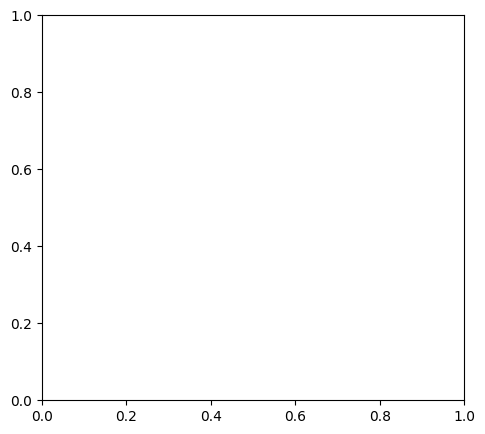

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Gráfico de Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy por Época')
plt.ylabel('Accuracy')
plt.xlabel('Época')
plt.legend()

# Gráfico de Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss por Época')
plt.ylabel('Loss')
plt.xlabel('Época')
plt.legend()

plt.tight_layout()
plt.show()

In [26]:
decoder.save('final_model.keras')

In [4]:
from tensorflow.keras.layers import Layer
from tensorflow.keras.models import load_model


# Definir la clase de atención nuevamente
class BahdanauAttention(Layer):
    def __init__(self, units, **kwargs):
        super(BahdanauAttention, self).__init__(**kwargs)
        self.W1 = tf.keras.layers.Dense(units)
        self.W2 = tf.keras.layers.Dense(units)
        self.V = tf.keras.layers.Dense(1)
        self.units = units

    def call(self, features, hidden):
        hidden_with_time_axis = tf.expand_dims(hidden, 1)
        score = self.V(tf.nn.tanh(
            self.W1(features) + self.W2(hidden_with_time_axis)))
        attention_weights = tf.nn.softmax(score, axis=1)
        context_vector = attention_weights * features
        context_vector = tf.reduce_sum(context_vector, axis=1)
        return context_vector, attention_weights

    def get_config(self):
        config = super().get_config()
        config.update({'units': self.units})
        return config

# Cargar el modelo con los objetos personalizados
try:
    model = load_model('final_model.keras', 
                    custom_objects={'BahdanauAttention': BahdanauAttention},
                    compile=False)
    model.compile(optimizer='adam', 
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])
    print("✅ Modelo cargado correctamente")
except Exception as e:
    print(f"Error al cargar el modelo: {str(e)}")

C:\Users\Gerard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\layer.py:391: UserWarning: `build()` was called on layer 'bahdanau_attention_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(



✅ Modelo cargado correctamente


C:\Users\Gerard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\layer.py:932: UserWarning: Layer 'bahdanau_attention_1' (of type BahdanauAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


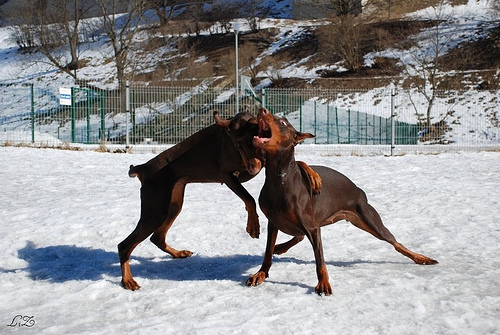


Descripciones reales:
the dogs are in the snow in front of a fence 
the dogs play on the snow 
two brown dogs playfully fight in the snow 
two brown dogs wrestle in the snow 
two dogs playing in the snow 

Descripción generada:


ValueError: Input 1 of layer "functional" is incompatible with the layer: expected shape=(None, 35), found shape=(1, 36)

In [ ]:
def generate_caption(model, encoder, image_path, word_to_idx, idx_to_word, max_length=36, temperature=0.5):  # Temperatura reducida
    """Genera descripción para una imagen con prevención de repetición"""
    # Preprocesar imagen
    img = Image.open(image_path).convert('RGB')
    img = img.resize((224, 224))
    img_array = np.expand_dims(np.array(img) / 255.0, axis=0)
    img_array = preprocess_input(img_array)
    
    # Extraer características
    feature = encoder.predict(img_array, verbose=0).reshape(1, -1)
    
    # Inicializar secuencia
    start_token = word_to_idx['<start>']
    end_token = word_to_idx['<end>']
    sequence = [start_token]
    last_words = []  # Para trackear repeticiones
    
    for _ in range(max_length):
        padded_seq = pad_sequences([sequence], maxlen=max_seq_length, padding='post')
        preds = model.predict(
            {'image_features': feature, 'caption_input': padded_seq},
            verbose=0
        )[0]
        
        # Penalización por repetición
        if len(last_words) >= 2:
            for word in set(last_words[-2:]):
                if word in idx_to_word:
                    preds[word_to_idx[word]] *= 0.3  # Penaliza palabras recientes
        
        # Aplicar temperatura
        preds = np.log(preds) / temperature
        exp_preds = np.exp(preds)
        preds = exp_preds / np.sum(exp_preds)
        
        # Filtrado más estricto
        valid_indices = [i for i in range(len(preds)) ]
                        if idx_to_word[i] not in ['<pad>', '<unk>', '<start>', '<end>'] and
                        (len(last_words) == 0 or idx_to_word[i] != idx_to_word[sequence[-1]])  # Evita repetición inmediata
        
        if not valid_indices:
            break
            
        valid_probs = preds[valid_indices]
        valid_probs /= np.sum(valid_probs)
        
        next_token = np.random.choice(valid_indices, p=valid_probs)
        sequence.append(next_token)
        last_words.append(idx_to_word[next_token])
        
        if next_token == end_token or len(sequence) >= max_length:
            break
    
    # Post-procesamiento mejorado
    caption_words = []
    for idx in sequence:
        word = idx_to_word[idx]
        if word not in ['<start>', '<end>', '<pad>']:
            caption_words.append(word)
    
    # Unir con lógica para evitar repeticiones consecutivas
    final_caption = []
    for i, word in enumerate(caption_words):
        if i == 0 or word != caption_words[i-1]:
            final_caption.append(word)
    
    caption = ' '.join(final_caption)
    
    # Capitalización y puntuación inteligente
    if caption:
        caption = caption.capitalize()
        if caption[-1] not in {'.', '!', '?'}:
            caption += '.'
        
    return caption
# Probar con una imagen de prueba
sample_img = list(test_descriptions.keys())[0]
sample_path = config.IMAGE_DIR / f"{sample_img}.jpg"

display(Image.open(sample_path))
print("\nDescripciones reales:")
print("\n".join(test_descriptions[sample_img]))
print("\nDescripción generada:")
print(generate_caption(decoder, encoder, sample_path, word_to_idx, idx_to_word))


 ## 11. Evaluación del modelo

In [ ]:
def evaluate_model(model, encoder, test_data, features, word_to_idx, idx_to_word, num_samples=50):
    """Evalúa el modelo con métricas BLEU"""
    actual = []
    predicted = []
    
    for img_id, desc_list in tqdm(list(test_data.items())[:num_samples], desc="Evaluando"):
        img_path = config.IMAGE_DIR / f"{img_id}.jpg"
        
        # Generar descripción
        gen_desc = generate_caption(model, encoder, img_path, word_to_idx, idx_to_word)
        
        # Procesar descripciones reales
        real_descs = [word_tokenize(desc.lower()) for desc in desc_list]
        
        actual.append(real_descs)
        predicted.append(word_tokenize(gen_desc.lower()))
    
    # Calcular BLEU
    smooth = SmoothingFunction().method4
    bleu1 = corpus_bleu(actual, predicted, weights=(1, 0, 0, 0), smoothing_function=smooth)
    bleu4 = corpus_bleu(actual, predicted, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth)
    
    print(f"\nBLEU-1: {bleu1:.4f}")
    print(f"BLEU-4: {bleu4:.4f}")
    
    return bleu1, bleu4

# Evaluar
bleu1, bleu4 = evaluate_model(decoder, encoder, test_descriptions, test_features, word_to_idx, idx_to_word)